# Frequency Estimation and Heavy Hitters
## Executive summary
### 1. Misra-Gries Algorithm (MG)
We implemented the Misra-Gries algorithm closely following the pseudocode provided in the lecture notes. The update function processes the incoming data stream under a strict memory constraint, defined by maxNumCounters. This parameter dictates the maximum number of distinct elements we can track simultaneously. When the dictionary reaches full capacity and a new, unmonitored element arrives, we identify the minimum counter value currently inside the dictionary, subtract this amount from all active counters, and remove any elements whose counts drop to zero. This ensures sufficient space for new elements. Finally, the query function retrieves the estimated frequency of a given element, returning 0 if the element is not currently tracked in our counters.

### 2. Count-Min sketch (CMS)
Similarly, we implemented the Count-Min sketch algorithm based on the lecture's pseudocode. To ensure the reproducibility of our experiments, we initialized the hash functions using a fixed random seed (42). The data structure relies on a 2D array where each row corresponds to an independent hash function, and each column represents a possible hashed value. For instance, a $5 \times 20$ grid implies 5 distinct hash functions, each mapping elements to a column index between 0 and 19. The update function processes the stream by hashing each element across all rows and incrementing the corresponding counters. The query function then estimates the frequency of an element by hashing it across all rows and returning the minimum value among these respective counters.

### Error measure
Measuring the error over the entire universe
$U$ using $$\sum_{x\in U}|f(x) - \hat{f}(x)|$$
 presents multiple problems. First, the universe is often intractably large (e.g., $U$ containing all possible strings), making it computationally impossible to calculate the exact sum. Second, the metric disproportionately penalizes specific algorithmic behaviors:
- **CMS** suffers from hash collisions, meaning every estimate is an overestimation ($\hat{f}(x) \ge f(x)$). Because Count-Min Sketch assigns non-zero estimates to millions of elements that never even appeared in the stream, summing these small, individual errors over the massive size of $U$ results in a giant aggregate error. This completely obscures how well the algorithm actually performs on the elements we care about.
- **MG** is designed exclusively to track up to $k$ heavy hitters, naturally discarding infrequent items. Using a global sum forces us to evaluate the algorithm on elements it was explicitly designed to ignore. Furthermore, for the elements it _does_ track, it consistently underestimates the true count because it subtracts values when space is limited.

#### Proposed Alternative
Because both algorithms are designed specifically to find heavy hitters, the evaluation should be restricted to those items. Let $\text{Top-K} \subseteq U$ be the set containing the $K$ true most frequent elements in the stream. A more appropriate measure is the Mean Absolute Error (MAE) over this subset:
$$\frac{1}{K} \sum_{x \in \text{Top-K}}|f(x) - \hat{f}(x)|$$

**Why this is better:**
The first problem is eliminated because we limit the evaluation to a small, known subset of $U$, making it computationally feasible. For the Misra-Gries algorithm, this metric perfectly captures its underestimation behavior on the exact elements it targets (assuming we match the evaluation $K$ to the algorithm's parameter $k$). For Count-Min Sketch, while the algorithm still overestimates, we are no longer aggregating the microscopic noise of millions of irrelevant, zero-frequency elements, allowing for a fair comparison of how well both methods estimate the most relevant data.


### Results of data skewness
(Note: More details about our testing methodology can be found further down).

The resulting graph shows that CMS yields a significantly lower error for less skewed distributions $(a < 1.5)$. However, as the skewness increases ($a \ge 1.5$), the error rates of both algorithms converge and perform almost equally well. This behavior is expected: in highly skewed distributions, a very small number of heavy hitters dominate the stream. Because the variety of frequent items is small, neither algorithm exhausts its memory budget, allowing both to track the top elements accurately. Conversely, in low-skew distributions, the stream contains a massive variety of distinct, low-frequency elements. For Misra-Gries, this constant influx of new items forces the algorithm to frequently decrement its counters to clear space. This aggressive decrementing systematically reduces the counts of the true heavy hitters, leading to a much higher error rate compared to CMS.

### Results of different parameters
(Note: More details about our testing methodology can be found further down).

Adjusting the memory budget and internal hyperparameters significantly impacts the accuracy, runtime, and resource consumption of both algorithms.

**Count-Min Sketch**:
As expected, increasing the total allocated space drastically reduces the error rate across all row configurations, since a larger number of columns inherently decreases the probability of hash collisions. Under strict memory constraints, optimizing for fewer rows (hash functions) in favor of more columns yields better accuracy and a lower standard deviation than employing many rows with limited columns.

Regarding computational performance, the runtime scales linearly with the number of rows due to the increased hashing overhead per incoming element, but remains largely unaffected by the total space allocated. Conversely, memory consumption is strictly dictated by the total space budget, scaling upward as expected regardless of how that space is partitioned between rows and columns.

**Misra-Gries Algorithm**:
Similar to CMS, the error rate in MG reliably declines as the maximum number of counters (space allocation) increases. However, the runtime behavior is highly non-linear with respect to space. We observed an initial increase in runtime as the space allocation grows from 200 to 1,000 counters, followed by a sharp decrease when 10,000 counters are allocated.

This behavior is tied to the algorithm's decrement operation. At very small capacities, the dictionary frequently reaches its limit, triggering an eviction process; however, scanning a small dictionary for the minimum counter is fast. At moderate capacities (e.g., 1,000), these minimum-value searches are still frequently triggered but require scanning a significantly larger data structure, causing a spike in runtime. When the capacity is increased to 10,000 (effectively covering the universe of distinct items in our stream), the dictionary rarely reaches capacity, almost entirely bypassing the expensive decrement operation. Finally, MG consistently exhibits a larger physical memory footprint than CMS. At an allocation parameter of 10,000, MG peaks at approximately 0.7 MB, compared to just 0.17 MB for CMS.


## Jupyter Notebook
### Import

In [15]:
import numpy as np
import tracemalloc
import time
from collections import Counter
import matplotlib.pyplot as plt

### Helper Functions

Below, we provide some helper functions that will be useful for this assignment.

First, we give a function for measuring the time and memory usage of function calls. To measure the time and memory usage of a function call ``myFunc(x,y,z)`` use the following code: ``measure_time_and_memory(myFunc, x, y, z)``.

In [16]:
def measure_time_and_memory(func, *args, **kwargs):
    tracemalloc.start()
    start_time = time.perf_counter()

    result = func(*args, **kwargs)

    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    return end_time - start_time, peak / 10 ** 6, result

We also provide an implementation of the simple tabulation hash function which returns a 32-bit integer hash value.

In [17]:
def simple_tab32(H):
    return lambda x: _simple_tab32(x, H)


def _simple_tab32(x: int, H: np.ndarray) -> int:
    h = 0
    for i in range(4):
        c = x & 0xFF  # Extract the lowest 8 bits
        h ^= H[i, c]
        x >>= 8
    return h

 You can use these hash functions as follows:

In [18]:
H = np.random.randint(0, 2 ** 32, size=(4, 256), dtype=np.uint32)
myHashFunc = simple_tab32(H)
print(myHashFunc(5))
print(myHashFunc(10))

3076983013
1834486911


You also find a function ``sample_zipf_like`` which allows for sampling from Zipfian distributions.

In [19]:
def sample_zipf_like(a, n, size):
    """
    Sample from a Zipf-like distribution over {1, ..., n} with exponent a.
    
    Parameters:
        a (float): Exponent (e.g., 0.5 for 1/sqrt(i))
        n (int): Maximum rank
        size (int): Number of samples to draw
        
    Returns:
        np.ndarray: Array of samples
    """
    weights = np.array([1 / (i ** a) for i in range(1, n + 1)])
    probabilities = weights / weights.sum()
    return np.random.choice(np.arange(1, n + 1), size=size, p=probabilities)

An example call is as follows:

In [20]:
a = 0.75
n = 10000
numSamples = 1000000

sample = sample_zipf_like(a, n, numSamples)

### Implementation of Frequency Estimation Data Structures

In [21]:
class DictionaryBaseline:
    def __init__(self):
        self.counters = {}

    def update(self, x, v):
        self.counters[x] = self.counters.get(x, 0) + v

    def query(self, x):
        return self.counters.get(x, 0)

In [22]:
class MisraGries:
    def __init__(self, maxNumCounters):
        # Initialize a set of counters that is initially empty
        self.counters = {}
        self.maxNumCounters = maxNumCounters

    def update(self, x, v):
        if v < 0: raise ValueError("MisraGries does not allow negative numbers")

        # if there exists a counter for x_i then
        if x in self.counters:
            # Increase the counter of x_i by v_i
            self.counters[x] += v

        else:
            # Create a new counter for x_i and initialize it with v_i
            self.counters[x] = v

            # if there are more than 1/ε counters then
            if len(self.counters) > self.maxNumCounters:
                # Find the value vmin of the smallest counter
                v_min = min(self.counters.values())

                for x_key in list(self.counters.keys()):
                    # Decrease all counters by v_min
                    self.counters[x_key] -= v_min
                    if self.counters[x_key] <= 0:
                        # Remove all counters that are 0
                        self.counters.pop(x_key)

    def query(self, x):
        # if there exists a counter for x then return the value of the counter for x else return 0
        return self.counters.get(x, 0)

In [23]:
class CountMinSketch:
    def __init__(self, numCols: int, numRows: int, hashSeed = 42):

        # numRows ~= k
        self.numRows = numRows
        # numCols ~= l
        self.numCols = numCols

        np.random.seed(hashSeed)

        # h_1, ..., h_k ← independently sample k pairwise independent hash functions mapping from U to [l]
        self.hashFunctions = []
        for _ in range(numRows): # 1, ..., k
            H = np.random.randint(0, 2 ** 32, size=(4, 256), dtype=np.uint32)
            self.hashFunctions.append(simple_tab32(H))

        # C ← an all-zeroes matrix of size k × ℓ
        self.C = np.zeros(shape=(numRows, numCols), dtype=np.int64)

    def update(self, x, v):
        if v < 0: raise ValueError("CountMinSketch does not allow negative numbers")

        for j, h_j in enumerate(self.hashFunctions): # j = 1, ..., k
            col = h_j(x) % self.numCols
            self.C[j, col] += v

    def query(self, x):
        return min(
            self.C[j, h_j(x) % self.numCols]
            for j, h_j in enumerate(self.hashFunctions) # j = 1, ..., k
        )


### Experimental Evaluation
This function evaluates both algorithms and compares them to an exact baseline. It uses the following parameters:
- `stream`: all the elements that should be processed using the algorithms
- `k_top`: the number of most relevant elements (heavy hitters) in the stream to evaluate against
- `mg_counters`: the maximum number of counters the Misra-Gries algorithm is allowed to use
- `cms_rows`: the number of rows (independent hash functions) in the Count-Min Sketch
- `cms_cols`: the number of columns (hash buckets or available slots for each hash function) the Count-Min Sketch uses

It returns a dictionary of measurements containing:
- Error (CMS and MG): Mean Absolute Error calculated over the k_top actual most frequent items.
- Standard Deviation (CMS only): The standard deviation of the absolute errors for the top-$K$ items.
- Time (CMS and MG): The runtime (in seconds) it took to process the entire stream with the respective algorithm.
- Memory (CMS and MG): The peak physical memory (in MB) consumed by the respective algorithm during execution.

In [24]:
def evaluate_algorithms(stream, k_top=100, mg_counters=500, cms_rows=5, cms_cols=200):
    # baseline
    baseline = DictionaryBaseline()
    for item in stream:
        baseline.update(item, 1)

    true_counts = Counter(baseline.counters)
    top_k_items = true_counts.most_common(k_top)

    # helper function for better tracking
    def run_misra_gries():
        mg = MisraGries(maxNumCounters=mg_counters)
        for item in stream:
            mg.update(item, 1)
        return mg

    def run_count_min_sketch():
        cms = CountMinSketch(numRows=cms_rows, numCols=cms_cols)
        for item in stream:
            cms.update(item, 1)
        return cms

    # misra-gries evaluation + measuring
    mg_time, mg_mem, mg = measure_time_and_memory(run_misra_gries)

    # count-min sketch evaluation + measuring
    cms_time, cms_mem, cms = measure_time_and_memory(run_count_min_sketch)

    # calculate error
    mg_error_sum = 0
    cms_error_sum = 0
    cms_errors = []

    for item, true_freq in top_k_items:
        mg_est = mg.query(item)
        cms_est = cms.query(item)

        mg_error_sum += abs(true_freq - mg_est)

        c_err = abs(true_freq - cms_est)
        cms_error_sum += c_err
        cms_errors.append(c_err)

    return {
        "mg_mae": mg_error_sum / k_top,
        "cms_mae": cms_error_sum / k_top,
        "cms_std": np.std(cms_errors),
        "mg_time": mg_time,
        "cms_time": cms_time,
        "mg_memory_mb": mg_mem,
        "cms_memory_mb": cms_mem
    }



### Skewness of the data
In this section, we evaluate how both algorithms perform across differently skewed distributions. To ensure a fair comparison, both algorithms are constrained to an equivalent memory footprint of 1,000 units. Since the Misra-Gries (MG) algorithm uses a dictionary that stores key-value pairs (requiring two memory units per entry), its maximum capacity is set to $k = 500$. In contrast, Count-Min Sketch (CMS) only stores single integer counters, allowing us to allocate a $5 \times 200$ matrix, which perfectly matches the 1,000-unit budget.

Started Skewness Evaluation...
1/5 Skewness: 0.25
2/5 Skewness: 0.5
3/5 Skewness: 1
4/5 Skewness: 1.5
5/5 Skewness: 2.0


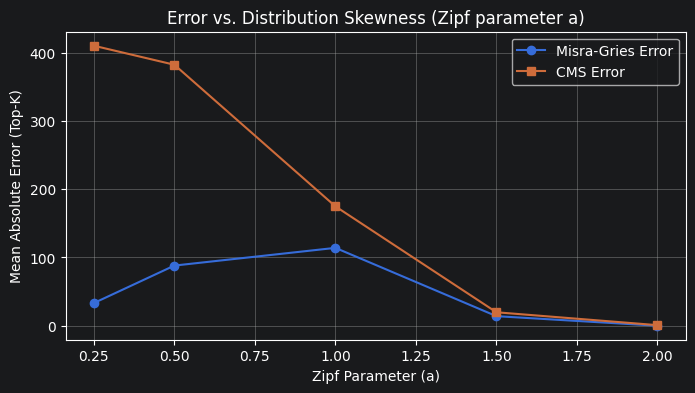

In [25]:
skews = [0.25, 0.5, 1, 1.5, 2.0]
mg_errors_skew = []
cms_errors_skew = []

print("Started Skewness Evaluation...")
for i, a in enumerate(skews):
    print(f"{i+1}/{len(skews)} Skewness: {a}")
    stream = sample_zipf_like(a, n=10000, size=100000)

    results = evaluate_algorithms(stream, mg_counters=500, cms_rows=5, cms_cols=200)
    mg_errors_skew.append(results["mg_mae"])
    cms_errors_skew.append(results["cms_mae"])

# plot (is generated by gemini)
plt.figure(figsize=(8, 4))
plt.plot(skews, mg_errors_skew, label='Misra-Gries Error', marker='o')
plt.plot(skews, cms_errors_skew, label='CMS Error', marker='s')
plt.title('Error vs. Distribution Skewness (Zipf parameter a)')
plt.xlabel('Zipf Parameter (a)')
plt.ylabel('Mean Absolute Error (Top-K)')
plt.legend()
plt.grid(True)
plt.show()

### Parameter sensitivity:
In this section, we evaluate the sensitivity of the Misra-Gries (MG) and Count-Min Sketch (CMS) algorithms to changes in their internal parameters. Using a stream generated from a moderately skewed distribution, we tracked multiple evaluation metrics across various total memory budgets. To maintain a fair evaluation for any given total space, MG was allocated a maximum number of counters equal to exactly half of the space budget (accounting for its two-word key-value storage). For CMS, we kept the total space strictly constant while varying the number of rows (hash functions), which inherently forced an inverse adjustment to the number of columns per row.

In [28]:
# parameters to test
rows_to_test = [2, 4, 5, 8, 10, 20]
total_space_to_test = [200, 1000, 10000]

# trackers
cms_errs_rows = {ts: [] for ts in total_space_to_test}
cms_stds_rows = {ts: [] for ts in total_space_to_test}
mg_errs_space = {ts: [] for ts in total_space_to_test}

cms_time_rows = {ts: [] for ts in total_space_to_test}
cms_mem_rows = {ts: [] for ts in total_space_to_test}
mg_time_space = {ts: [] for ts in total_space_to_test}
mg_mem_space = {ts: [] for ts in total_space_to_test}

# moderately skewed distribution with 500000 datapoints
stream = sample_zipf_like(1, n=10000, size=500000) # change to 100000 to have better runtime

print("Running Hyperparameter Testing...")
for i, total_space in enumerate(total_space_to_test):
    mg_mae_avg = 0
    mg_time_avg = 0
    mg_memory_avg = 0
    for j, r in enumerate(rows_to_test):
        current_iter = (i * len(rows_to_test)) + j + 1
        print(f"{current_iter}/{len(rows_to_test)*len(total_space_to_test)} Currently parameters: total_spaces: {total_space} rows: {r}")
        c = total_space // r
        res = evaluate_algorithms(stream, mg_counters=total_space//2, cms_rows=r, cms_cols=c)

        cms_errs_rows[total_space].append(res["cms_mae"])
        cms_stds_rows[total_space].append(res["cms_std"])
        cms_time_rows[total_space].append(res["cms_time"])
        cms_mem_rows[total_space].append(res["cms_memory_mb"])

        mg_mae_avg += res["mg_mae"]
        mg_time_avg += res["mg_time"]
        mg_memory_avg += res["mg_memory_mb"]

    mg_errs_space[total_space].append(mg_mae_avg / len(rows_to_test))
    mg_time_space[total_space].append(mg_time_avg / len(rows_to_test))
    mg_mem_space[total_space].append(mg_memory_avg / len(rows_to_test))

Running Hyperparameter Testing...
1/18 Currently parameters: total_spaces: 200 rows: 2
2/18 Currently parameters: total_spaces: 200 rows: 4
3/18 Currently parameters: total_spaces: 200 rows: 5
4/18 Currently parameters: total_spaces: 200 rows: 8
5/18 Currently parameters: total_spaces: 200 rows: 10
6/18 Currently parameters: total_spaces: 200 rows: 20
7/18 Currently parameters: total_spaces: 1000 rows: 2
8/18 Currently parameters: total_spaces: 1000 rows: 4
9/18 Currently parameters: total_spaces: 1000 rows: 5
10/18 Currently parameters: total_spaces: 1000 rows: 8
11/18 Currently parameters: total_spaces: 1000 rows: 10
12/18 Currently parameters: total_spaces: 1000 rows: 20
13/18 Currently parameters: total_spaces: 10000 rows: 2
14/18 Currently parameters: total_spaces: 10000 rows: 4
15/18 Currently parameters: total_spaces: 10000 rows: 5
16/18 Currently parameters: total_spaces: 10000 rows: 8
17/18 Currently parameters: total_spaces: 10000 rows: 10
18/18 Currently parameters: total_sp

##### Plot the data
This part is AI generated using gemini.

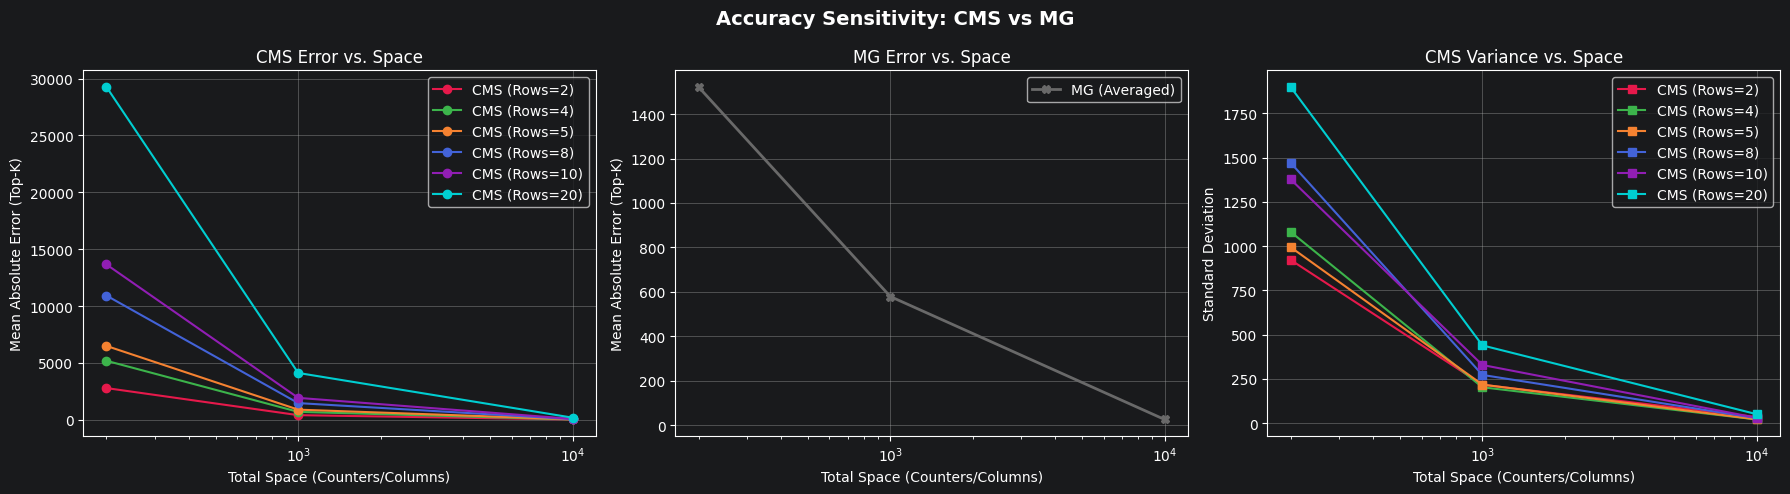

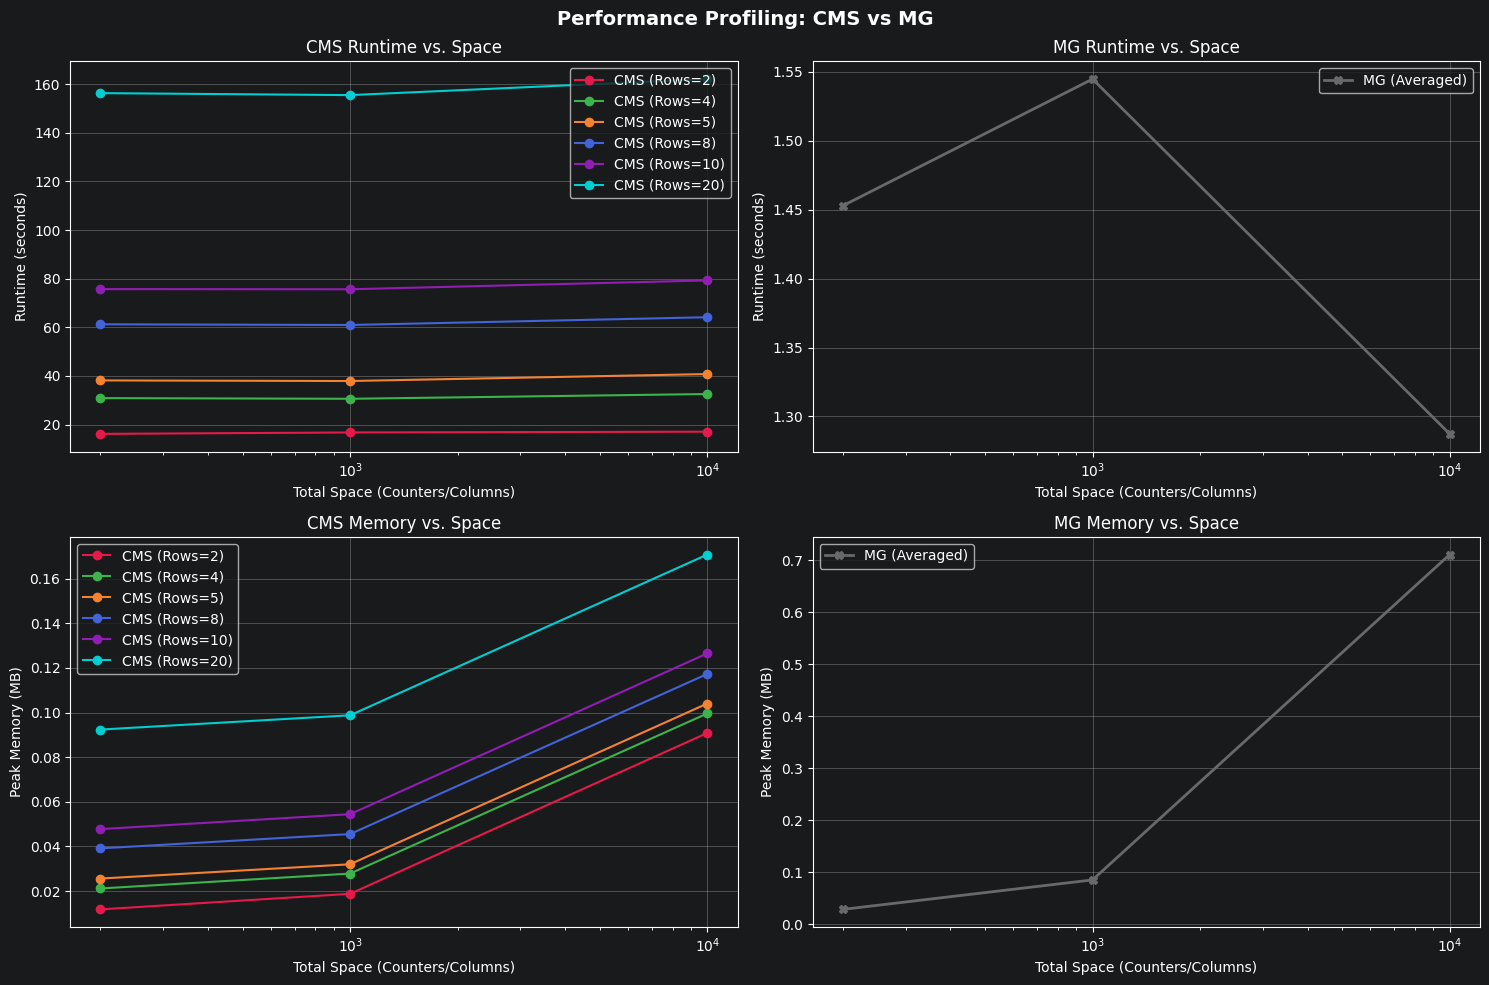

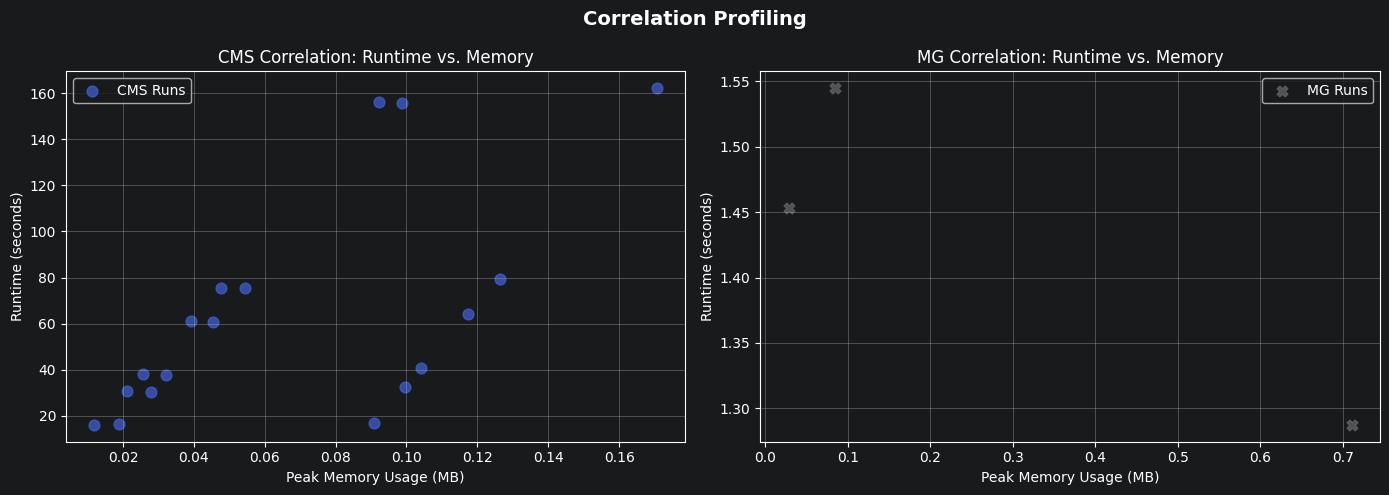

In [30]:
# Updated to more distinct categorical colors for the different row parameters
cms_colors = ['#e6194b', '#3cb44b', '#f58231', '#4363d8', '#911eb4', '#00ced1']
mg_color = '#696969' # Black for the single MG line

# ==========================================
# FIGURE 1: ACCURACY (Error & Standard Deviation)
# ==========================================
# 3 subplots: CMS Error, MG Error, CMS Variance
fig1, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

# Extract MG data (1 averaged value per space)
mg_errs = [mg_errs_space[ts][0] for ts in total_space_to_test]
ax2.plot(total_space_to_test, mg_errs, marker='X', color=mg_color, label='MG (Averaged)', linewidth=2)

# Plot CMS lines (one line per row parameter)
for r_idx, r in enumerate(rows_to_test):
    cms_errs = [cms_errs_rows[ts][r_idx] for ts in total_space_to_test]
    cms_stds = [cms_stds_rows[ts][r_idx] for ts in total_space_to_test]

    ax1.plot(total_space_to_test, cms_errs, marker='o', color=cms_colors[r_idx % len(cms_colors)], label=f'CMS (Rows={r})')
    ax3.plot(total_space_to_test, cms_stds, marker='s', color=cms_colors[r_idx % len(cms_colors)], label=f'CMS (Rows={r})')

for ax in (ax1, ax2, ax3):
    ax.set_xscale('log') # Log scale prevents crowding for values [200, 1k, 10k, 1M]
    ax.set_xlabel('Total Space (Counters/Columns)')
    ax.grid(True)
    ax.legend()

ax1.set_ylabel('Mean Absolute Error (Top-K)')
ax1.set_title('CMS Error vs. Space')

ax2.set_ylabel('Mean Absolute Error (Top-K)')
ax2.set_title('MG Error vs. Space')

ax3.set_ylabel('Standard Deviation')
ax3.set_title('CMS Variance vs. Space')

fig1.suptitle('Accuracy Sensitivity: CMS vs MG', fontsize=14, fontweight='bold')
fig1.tight_layout()

# ==========================================
# FIGURE 2: PERFORMANCE (Runtime & Memory)
# ==========================================
# 4 subplots: Runtime (CMS, MG) and Memory (CMS, MG)
fig2, ((ax4, ax5), (ax6, ax7)) = plt.subplots(2, 2, figsize=(15, 10))

# Extract MG Data
mg_time = [mg_time_space[ts][0] for ts in total_space_to_test]
mg_mem = [mg_mem_space[ts][0] for ts in total_space_to_test]

ax5.plot(total_space_to_test, mg_time, marker='X', color=mg_color, label='MG (Averaged)', linewidth=2)
ax7.plot(total_space_to_test, mg_mem, marker='X', color=mg_color, label='MG (Averaged)', linewidth=2)

# Extract CMS Data per Row
for r_idx, r in enumerate(rows_to_test):
    cms_time = [cms_time_rows[ts][r_idx] for ts in total_space_to_test]
    cms_mem = [cms_mem_rows[ts][r_idx] for ts in total_space_to_test]

    ax4.plot(total_space_to_test, cms_time, marker='o', color=cms_colors[r_idx % len(cms_colors)], label=f'CMS (Rows={r})')
    ax6.plot(total_space_to_test, cms_mem, marker='o', color=cms_colors[r_idx % len(cms_colors)], label=f'CMS (Rows={r})')

for ax in (ax4, ax5, ax6, ax7):
    ax.set_xscale('log')
    ax.set_xlabel('Total Space (Counters/Columns)')
    ax.grid(True)
    ax.legend()

ax4.set_ylabel('Runtime (seconds)')
ax4.set_title('CMS Runtime vs. Space')

ax5.set_ylabel('Runtime (seconds)')
ax5.set_title('MG Runtime vs. Space')

ax6.set_ylabel('Peak Memory (MB)')
ax6.set_title('CMS Memory vs. Space')

ax7.set_ylabel('Peak Memory (MB)')
ax7.set_title('MG Memory vs. Space')

fig2.suptitle('Performance Profiling: CMS vs MG', fontsize=14, fontweight='bold')
fig2.tight_layout()

# ==========================================
# FIGURE 3: CORRELATION (Runtime vs Memory)
# ==========================================
# 2 subplots separated by CMS and MG
fig3, (ax8, ax9) = plt.subplots(1, 2, figsize=(14, 5))

# Gather all data points for the scatter plot
all_cms_time = [t for ts in total_space_to_test for t in cms_time_rows[ts]]
all_cms_mem = [m for ts in total_space_to_test for m in cms_mem_rows[ts]]
all_mg_time = [mg_time_space[ts][0] for ts in total_space_to_test]
all_mg_mem = [mg_mem_space[ts][0] for ts in total_space_to_test]

ax8.scatter(all_cms_mem, all_cms_time, color='#4363d8', alpha=0.7, marker='o', s=60, label='CMS Runs')
ax9.scatter(all_mg_mem, all_mg_time, color=mg_color, alpha=0.7, marker='X', s=60, label='MG Runs')

for ax in (ax8, ax9):
    ax.set_xlabel('Peak Memory Usage (MB)')
    ax.set_ylabel('Runtime (seconds)')
    ax.grid(True)
    ax.legend()

ax8.set_title('CMS Correlation: Runtime vs. Memory')
ax9.set_title('MG Correlation: Runtime vs. Memory')

fig3.suptitle('Correlation Profiling', fontsize=14, fontweight='bold')
fig3.tight_layout()

plt.show()